In [214]:
import tensorflow as tf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

import copy
import random
import math

from sqlalchemy import create_engine
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import CSVLogger

from datetime import datetime

In [61]:
dbConnectionString = "sqlite:///baseball_info.db"

engine = create_engine(dbConnectionString)

In [216]:
timeSeriesHittingQuery = "SELECT SeasonStatsHitting.playerId,season,Bios.dob,plateAppearances,atBats,runs,hits,singles,doubles,triples,homeRuns,rbis,sacHits,sacFlies,hitByPitch,walks,intentionalWalks,strikeOuts,stolenBases,caughtStealing,groundedIntoDoublePlays,catcherInterference,battingAverage,onBasePercentage,sluggingPercentage,onBasePlusSlugging,runsPerTob,rbisPerBip FROM SeasonStatsHitting INNER JOIN Bios on Bios.playerId = SeasonStatsHitting.playerId WHERE season BETWEEN 2018 and 2025 and season != 2020 ORDER BY SeasonStatsHitting.playerId,season"

df = pd.read_sql(timeSeriesHittingQuery, engine)

In [217]:
len(df)

6989

In [218]:
hasMultipleSeasons = df["playerId"].value_counts() > 1
df = df[df["playerId"].isin(hasMultipleSeasons[hasMultipleSeasons].index)]

In [219]:
df.drop(df[df['plateAppearances'] == 0].index, inplace=True)

In [220]:
len(df)

3672

In [221]:
def calculate_age_from_timestamps(birth_timestamp, current_timestamp):
    birth_date   = datetime.fromtimestamp(birth_timestamp)
    current_date = datetime.fromtimestamp(current_timestamp)

    age = current_date.year - birth_date.year

    # Adjust age if the birthday hasn't occurred yet in the current year
    if (current_date.month, current_date.day) < (birth_date.month, birth_date.day):
        age -= 1
    
    return age

In [222]:
twentyEighteenDateString    = "2018-03-29 00:00:00"
twentyNineteenDateString    = "2019-03-20 00:00:00"
twentyTwentyOneDateString   = "2021-04-01 00:00:00"
twentyTwentyTwoDateString   = "2022-04-07 00:00:00"
twentyTwentyThreeDateString = "2023-03-30 00:00:00"
twentyTwentyFourDateString  = "2024-03-20 00:00:00"
twentyTwentyFiveDateString  = "2025-03-18 00:00:00"

# Parse the string into a datetime object
twentyEighteenDateString    = datetime.strptime(twentyEighteenDateString    , "%Y-%m-%d %H:%M:%S")
twentyNineteenDateString    = datetime.strptime(twentyNineteenDateString    , "%Y-%m-%d %H:%M:%S")
twentyTwentyOneDateString   = datetime.strptime(twentyTwentyOneDateString   , "%Y-%m-%d %H:%M:%S")
twentyTwentyTwoDateString   = datetime.strptime(twentyTwentyTwoDateString   , "%Y-%m-%d %H:%M:%S")
twentyTwentyThreeDateString = datetime.strptime(twentyTwentyThreeDateString , "%Y-%m-%d %H:%M:%S")
twentyTwentyFourDateString  = datetime.strptime(twentyTwentyFourDateString  , "%Y-%m-%d %H:%M:%S")
twentyTwentyFiveDateString  = datetime.strptime(twentyTwentyFiveDateString  , "%Y-%m-%d %H:%M:%S")

# Convert to Unix timestamp
twentyEighteenTimeStamp    = int(twentyEighteenDateString    .timestamp())
twentyNineteenTimeStamp    = int(twentyNineteenDateString    .timestamp())
twentyTwentyOneTimeStamp   = int(twentyTwentyOneDateString   .timestamp())
twentyTwentyTwoTimeStamp   = int(twentyTwentyTwoDateString   .timestamp())
twentyTwentyThreeTimeStamp = int(twentyTwentyThreeDateString .timestamp())
twentyTwentyFourTimeStamp  = int(twentyTwentyFourDateString  .timestamp())
twentyTwentyFiveTimeStamp  = int(twentyTwentyFiveDateString  .timestamp())

seasonToStartTimeStamp = {}

seasonToStartTimeStamp[2018] = twentyEighteenTimeStamp   
seasonToStartTimeStamp[2019] = twentyNineteenTimeStamp   
seasonToStartTimeStamp[2021] = twentyTwentyOneTimeStamp  
seasonToStartTimeStamp[2022] = twentyTwentyTwoTimeStamp  
seasonToStartTimeStamp[2023] = twentyTwentyThreeTimeStamp
seasonToStartTimeStamp[2024] = twentyTwentyFourTimeStamp 
seasonToStartTimeStamp[2025] = twentyTwentyFiveTimeStamp

#df['colD'] = df.apply(lambda row: row['colA'] + row['colB'], axis=1)

df['dob'] = df.apply(lambda row: calculate_age_from_timestamps(row['dob'], seasonToStartTimeStamp[row['season']]), axis=1)

In [223]:
logColumns = df.columns[3:]

df[logColumns] = np.log(df[logColumns] + 1)
# ['plateAppearances', 'atBats', 'col_d']
# df[3,:]           = np.log(df[3,:] + 1)
# df['rbis']        = np.log(df['rbis'] + 1)
# df['homeRuns']    = np.log(df['homeRuns'] + 1)
# df['stolenBases'] = np.log(df['stolenBases'] + 1)

In [224]:
df.head()

,playerId,season,dob,plateAppearances,atBats,runs,hits,singles,doubles,triples,...,stolenBases,caughtStealing,groundedIntoDoublePlays,catcherInterference,battingAverage,onBasePercentage,sluggingPercentage,onBasePlusSlugging,runsPerTob,rbisPerBip
8,405395,2018,38,6.212606,6.144186,3.931826,4.744932,4.330733,3.044522,0.0,...,0.693147,0.000000,2.564949,0.0,0.219265,0.253988,0.344123,0.530575,0.221542,0.078867
9,405395,2019,39,6.302619,6.198479,4.025352,4.795791,4.330733,3.135494,0.0,...,1.386294,0.000000,3.091042,0.0,0.218653,0.265887,0.357489,0.550617,0.201941,0.115569
10,405395,2021,41,5.693732,5.620401,3.401197,4.189655,3.828641,1.386294,0.0,...,1.098612,0.000000,2.708050,0.0,0.212175,0.249812,0.359580,0.540294,0.164755,0.095716
11,405395,2022,42,5.863631,5.730100,3.761200,4.430817,3.828641,2.708050,0.0,...,0.693147,1.098612,2.639057,0.0,0.239299,0.296193,0.438570,0.639334,0.170221,0.101828
17,408234,2018,34,5.062595,4.905275,2.890372,3.713572,3.295837,2.484907,0.0,...,0.000000,0.000000,1.945910,0.0,0.261215,0.332826,0.370018,0.611213,0.212922,0.145639


In [225]:
n = len(df)
#update indexes so that they dont split players between train and val, val and test

trainIndexStop = int(n*0.7)

dfRow = df.iloc[trainIndexStop]

playerId    = dfRow["playerId"]
curPlayerId = dfRow["playerId"]

while trainIndexStop < len(df) and curPlayerId == playerId:
    trainIndexStop += 1
    curPlayerId =  df.iloc[trainIndexStop]["playerId"]

valIndexStop = int(n*0.9)

dfRow = df.iloc[valIndexStop]

playerId    = dfRow["playerId"]
curPlayerId = dfRow["playerId"]

while valIndexStop < len(df) and curPlayerId == playerId:
    valIndexStop += 1
    curPlayerId =  df.iloc[valIndexStop]["playerId"]

train_df = df[0:trainIndexStop]
val_df   = df[trainIndexStop:valIndexStop]
test_df  = df[valIndexStop:]

num_features = df.shape[1]

In [226]:
numericTrainDf     = train_df.select_dtypes(include=np.number)
categoricalTrainDf = train_df.select_dtypes(exclude=np.number)

numericValDf       = val_df.select_dtypes(include=np.number)
categoricalValDf   = val_df.select_dtypes(exclude=np.number)

numericTestDf      = test_df.select_dtypes(include=np.number)
categoricalTestDf  = test_df.select_dtypes(exclude=np.number)

In [227]:
trainMean = numericTrainDf.mean()
trainStd  = numericTrainDf.std()

In [228]:
trainDfNormalized = (numericTrainDf - trainMean) / trainStd
valDfNormalized   = (numericValDf   - trainMean) / trainStd
testDfNormalized  = (numericTestDf  - trainMean) / trainStd

In [229]:
trainDfNormalized = pd.concat([categoricalTrainDf, trainDfNormalized], axis=1)
valDfNormalized   = pd.concat([categoricalValDf  , valDfNormalized]  , axis=1)
testDfNormalized  = pd.concat([categoricalTestDf , testDfNormalized] , axis=1)

C:\Users\graye\AppData\Local\Temp\ipykernel_37808\3977247016.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _  = ax.set_xticklabels(numericDf.keys(), rotation=90)


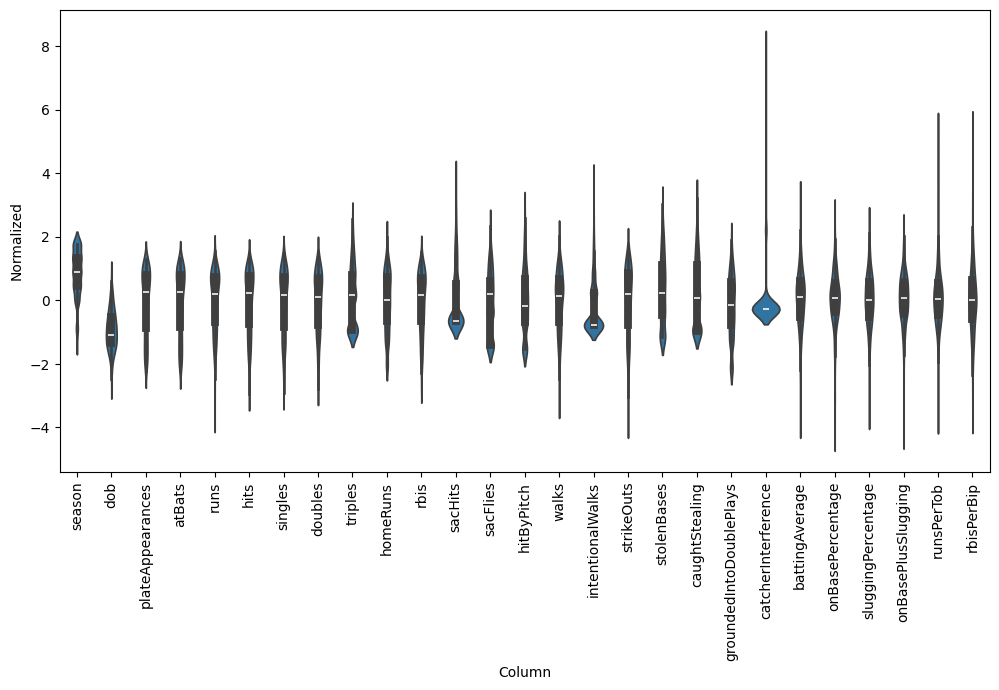

In [242]:
numericDf = val_df.select_dtypes(include=np.number)

dfStd = (numericValDf - trainMean) / trainStd
dfStd = dfStd.melt(var_name='Column', value_name='Normalized')

plt.figure(figsize=(12, 6))
ax = sns.violinplot(x='Column', y='Normalized', data=dfStd)
_  = ax.set_xticklabels(numericDf.keys(), rotation=90)

C:\Users\graye\AppData\Local\Temp\ipykernel_37808\2762546625.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _  = ax.set_xticklabels(numericDf.keys(), rotation=90)


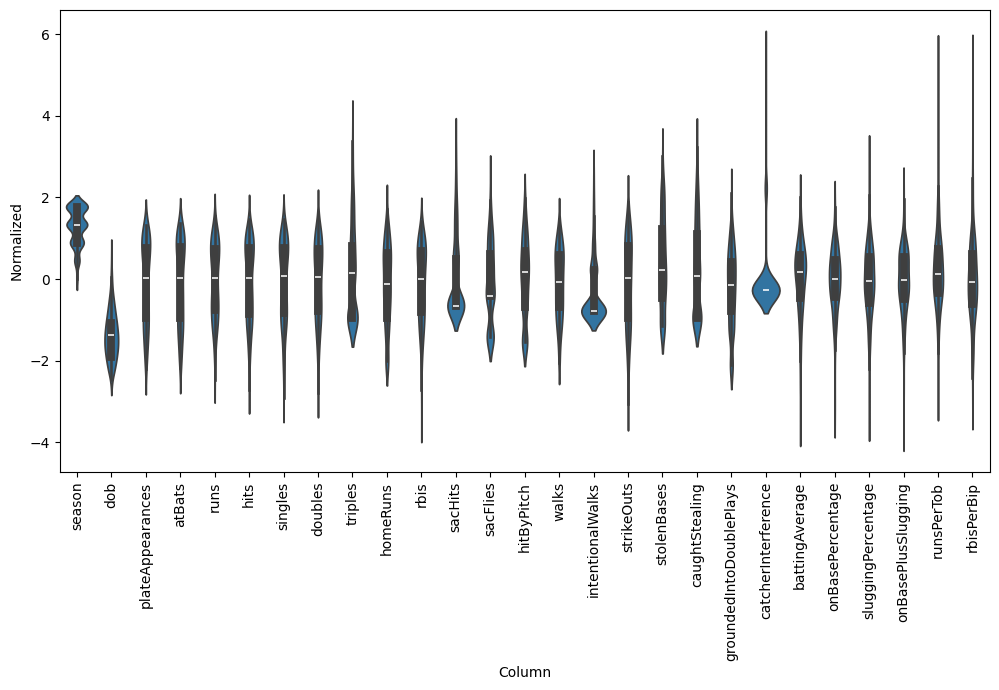

In [244]:
dfStd = (numericTestDf - trainMean) / trainStd
dfStd = dfStd.melt(var_name='Column', value_name='Normalized')

plt.figure(figsize=(12, 6))
ax = sns.violinplot(x='Column', y='Normalized', data=dfStd)
_  = ax.set_xticklabels(numericDf.keys(), rotation=90)

In [231]:
trainDfNormalized.head()

,playerId,season,dob,plateAppearances,atBats,runs,hits,singles,doubles,triples,...,stolenBases,caughtStealing,groundedIntoDoublePlays,catcherInterference,battingAverage,onBasePercentage,sluggingPercentage,onBasePlusSlugging,runsPerTob,rbisPerBip
8,405395,-1.308885,2.574763,0.817708,0.875853,0.565401,0.797554,0.846415,0.642281,-0.948667,...,-0.468388,-0.951262,1.018073,-0.273099,0.246617,-0.224784,0.291702,0.124181,-0.611331,-0.207540
9,405395,-0.868709,2.855735,0.937303,0.948195,0.665978,0.854498,0.846415,0.745094,-0.948667,...,0.217223,-0.951262,1.660910,-0.273099,0.230770,0.052101,0.475234,0.345495,-0.884192,0.909206
10,405395,0.011642,3.417680,0.128310,0.177943,-0.005230,0.175830,0.262468,-1.231785,-0.948667,...,-0.067331,-0.951262,1.192929,-0.273099,0.063086,-0.321973,0.503940,0.231502,-1.401854,0.305112
11,405395,0.451818,3.698653,0.354045,0.324110,0.381913,0.445850,0.262468,0.262013,-0.948667,...,-0.468388,0.673433,1.108626,-0.273099,0.765171,0.757348,1.588585,1.325156,-1.325764,0.491094
17,408234,-1.308885,1.450872,-0.710245,-0.774917,-0.554565,-0.357221,-0.357199,0.009825,-0.948667,...,-1.153998,-0.951262,0.261666,-0.273099,1.332455,1.609831,0.647275,1.014634,-0.731332,1.824140


In [232]:
def getWindowedFeaturesAndLabels(frame, maxWindowSize):
    frameArray = frame.values.tolist()

    inputs = []
    labels = []
    
    r = 0

    curWindow = []

    playerId = frameArray[0][0]
    
    while r < len(frameArray):
        curPlayerId = frameArray[r][0]

        if curPlayerId != playerId:
            window = []
            
            windowR = 0

            while windowR <= len(curWindow):
                if len(window) == maxWindowSize or windowR == len(curWindow):
                    label = window.pop()

                    labelTest = copy.deepcopy(label)

                    relevantLabels = labelTest[5:6] + labelTest[10:12] + labelTest[18:19] + labelTest[25:26]

                    if len(window) < maxWindowSize - 1:
                        diff = maxWindowSize - 1 - len(window)

                        while diff > 0:
                            padding = [0] * 28
                            window.append(padding)

                            diff -= 1

                    windowArray = [inner_list[2:] for inner_list in window]

                    # print(relevantLabels)
                    # print(windowArray)

                    # return

                    inputs.append(copy.deepcopy(windowArray))
                    labels.append(copy.deepcopy(relevantLabels))

                    window.append(label)
                    window.pop(0)

                if windowR < len(curWindow):
                    window.append(curWindow[windowR])
                
                windowR += 1

            curWindow = []
            playerId  = curPlayerId

        curWindow.append(frameArray[r])

        r += 1

    return inputs,labels

In [233]:
trainFeatures,trainLabels = getWindowedFeaturesAndLabels(trainDfNormalized, 4)
valFeatures,valLabels     = getWindowedFeaturesAndLabels(valDfNormalized  , 4)
testFeatures,testLabels   = getWindowedFeaturesAndLabels(testDfNormalized , 4)

trainFeaturesArray = np.array(trainFeatures)
trainLabelsArray   = np.array(trainLabels  )

valFeaturesArray = np.array(valFeatures)
valLabelsArray   = np.array(valLabels  )

testFeaturesArray = np.array(testFeatures)
testLabelsArray   = np.array(testLabels  )

In [234]:
trainFeaturesArray

array([[[ 2.57476254,  0.81770763,  0.87585273, ...,  0.12418146,
         -0.61133071, -0.20754001],
        [ 2.85573514,  0.93730253,  0.94819479, ...,  0.34549473,
         -0.88419221,  0.90920642],
        [ 3.41768034,  0.12830986,  0.17794302, ...,  0.23150248,
         -1.40185436,  0.3051117 ]],

       [[ 1.45087213, -0.71024546, -0.77491677, ...,  1.01463366,
         -0.73133221,  1.82413994],
        [ 1.73184473,  0.94700069,  0.95360022, ...,  0.40472325,
         -1.59424033,  0.13813648],
        [ 2.29378994,  0.89024412,  0.89571902, ...,  0.13244941,
         -0.94384892,  0.98852334]],

       [[ 1.73184473,  0.94700069,  0.95360022, ...,  0.40472325,
         -1.59424033,  0.13813648],
        [ 2.29378994,  0.89024412,  0.89571902, ...,  0.13244941,
         -0.94384892,  0.98852334],
        [ 2.57476254,  0.63228027,  0.66568275, ..., -0.39231145,
         -1.65952552,  0.39478969]],

       ...,

       [[-1.92079908, -1.7361373 , -1.68865755, ...,  1.0987628

In [235]:
#l2/l1 regularization, dropout, activation function, optmizier, loss function, hidden units, hidden layers, batch size, batch normalization

def get_model():
    model = tf.keras.Sequential([
        layers.Input(shape=(3, 26)),
        layers.Masking(mask_value=0., input_shape=(3, 26)),
        layers.LSTM(units= 20, dropout=0.2, recurrent_dropout=0.2, kernel_regularizer=regularizers.l2(0.001), return_sequences=False),
        layers.LayerNormalization(),
        layers.Dense(units = 5)
    ])

    return model

In [236]:
curModel = get_model()

C:\Users\graye\dev\python\fantasyBaseballPlayerData\player_projections\player_projections_env\Lib\site-packages\keras\src\layers\core\masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [237]:
curModel.compile(optimizer = tf.keras.optimizers.Adam(), loss="mse", metrics=[tf.keras.metrics.R2Score()])

In [238]:
curModel.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┓
┃ Layer (type)                        ┃ Output Shape               ┃        Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━┩
│ masking_12 (Masking)                │ (None, 3, 26)              │              0 │
├─────────────────────────────────────┼────────────────────────────┼────────────────┤
│ lstm_12 (LSTM)                      │ (None, 20)                 │          3,760 │
├─────────────────────────────────────┼────────────────────────────┼────────────────┤
│ layer_normalization_12              │ (None, 20)                 │             40 │
│ (LayerNormalization)                │                            │                │
├─────────────────────────────────────┼────────────────────────────┼────────────────┤
│ dense_12 (Dense)                    │ (None, 5)                  │            105 │
└─────────────────────────────────────┴────────────────────────────┴────────────────┘

 Total params: 3,905 (15.25 KB)

 Trainable params: 3,905 (15.25 KB)

 Non-trainable params: 0 (0.00 B)

In [239]:
callback = tf.keras.callbacks.EarlyStopping(patience=10)

In [240]:
csvLogger = CSVLogger('./shuffled_training_permutations/no_shuffle_training_log.csv')

In [241]:
#history =
curModel.fit(trainFeaturesArray, trainLabelsArray, batch_size=32, epochs=50, validation_data=(valFeaturesArray, valLabelsArray))#, callbacks=[callback])

Epoch 1/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 1.8118 - r2_score: -0.6344 - val_loss: 1.1716 - val_r2_score: -0.2075
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.2260 - r2_score: -0.0879 - val_loss: 0.9550 - val_r2_score: 0.0226
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0149 - r2_score: 0.1056 - val_loss: 0.8527 - val_r2_score: 0.1311
Epoch 4/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9260 - r2_score: 0.1856 - val_loss: 0.7944 - val_r2_score: 0.1909
Epoch 5/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.8698 - r2_score: 0.2371 - val_loss: 0.7566 - val_r2_score: 0.2307
Epoch 6/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.8167 - r2_score: 0.2847 - val_loss: 0.7271 - val_r2_score: 0.2603
Epoch 7/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.8040 - r2_score: 0.2965 - val_loss: 0.7169 - val_r2_score: 0.2697
Epoch 8/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7643 - r2_score: 0.3318 - val_loss: 0.6836 - val_r2_sc

In [ ]:
loss: 0.3984 - r2_score: 0.6263 - val_loss: 0.4158 - val_r2_score: 0.5821

In [ ]:
baselineTraining = pd.read_csv('./shuffled_training_permutations/no_shuffle_training_log.csv')

baselineTrainingLoss    = baselineTraining['loss'    ][49]
baselineTrainingValLoss = baselineTraining['val_loss'][49]

shuffledIndexToTrainingLossRatio = {}
shuffledIndexToValLossRatio      = {}

for featureIndex in range(trainFeaturesArray.shape[2]):
    csvFilePath = './shuffled_training_permutations/' + str(featureIndex) + '_shuffled_training_log.csv'

    shuffledTraining = pd.read_csv(csvFilePath)

    shuffledTrainingLoss    = shuffledTraining['loss'    ][49]
    shuffledTrainingValLoss = shuffledTraining['val_loss'][49]

    shuffledTrainingLossRatio = shuffledTrainingLoss / baselineTrainingLoss
    shuffledValLossRatio      = shuffledTrainingValLoss / baselineTrainingValLoss

    shuffledIndexToTrainingLossRatio[featureIndex] = shuffledTrainingLossRatio
    shuffledIndexToValLossRatio     [featureIndex] = shuffledValLossRatio

    print(str(featureIndex) + ", training loss ratio: " + str(shuffledTrainingLossRatio) + ", val loss ratio: " + str(shuffledValLossRatio))    

In [208]:
baselineResults = curModel.evaluate(testFeaturesArray, testLabelsArray)

print(baselineResults[0])
print(baselineResults[1])

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6419 - r2_score: 0.1566 
0.6419216990470886
0.15657849609851837


In [ ]:
7ms/step - loss: 0.7388 - r2_score: 0.2671 

In [162]:
for featureIndex in range(testFeaturesArray.shape[2]):
   print(train_df.columns[featureIndex+2])
   shuffledTestFeaturesArray = testFeaturesArray.copy()

   testColumnElements = [shuffledTestFeaturesArray[i][j][featureIndex] for i in range(len(shuffledTestFeaturesArray)) for j in range(len(shuffledTestFeaturesArray[i]))]

   random.shuffle(testColumnElements)
   
   k = 0
   
   for i in range(len(shuffledTestFeaturesArray)):
       for j in range(len(shuffledTestFeaturesArray[i])):
           shuffledTestFeaturesArray[i][j][featureIndex] = testColumnElements[k]
   
           k += 1

   shuffledResults = curModel.evaluate(shuffledTestFeaturesArray, testLabelsArray)

   #print(shuffledResults[0] / baselineResults[0])
   print(shuffledResults[1] / baselineResults[1])

dob
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.6918 - r2_score: 0.2450
0.9634919081772496
plateAppearances
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.7207 - r2_score: 0.2133
0.8388759042914404
atBats
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.7322 - r2_score: 0.1982 
0.7793436310403036
runs
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.7360 - r2_score: 0.2042 
0.80308116782864
hits
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.7032 - r2_score: 0.2255 
0.8867307114276892
singles
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7178 - r2_score: 0.2254 
0.8862523092499486
doubles
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7468 - r2_score: 0.1811 
0.7119082592781606
triples
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6771 - r2_score: 0.2673 
1.0510331201958374
homeRuns
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7551 - r2_score: 0.1709 
0.6719261415004075
rbis
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7156 - r2_score: 0.2220 
0.8730494637969958
sacHits
7/7 ━━━━

In [211]:
thomasPrediction = curModel.predict(np.array([testFeaturesArray[1]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 721ms/step


In [212]:
runs     = (thomasPrediction[0][0] * trainStd[4] ) + trainMean[4]
homeRuns = (thomasPrediction[0][1] * trainStd[9] ) + trainMean[9]
rbis     = (thomasPrediction[0][2] * trainStd[10]) + trainMean[10]
sbs      = (thomasPrediction[0][3] * trainStd[17]) + trainMean[17]
obp      = (thomasPrediction[0][4] * trainStd[22]) + trainMean[22]

C:\Users\graye\AppData\Local\Temp\ipykernel_37808\1898145955.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  runs     = (thomasPrediction[0][0] * trainStd[4] ) + trainMean[4]
C:\Users\graye\AppData\Local\Temp\ipykernel_37808\1898145955.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  homeRuns = (thomasPrediction[0][1] * trainStd[9] ) + trainMean[9]
C:\Users\graye\AppData\Local\Temp\ipykernel_37808\1898145955.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value 

In [215]:
print(math.exp(runs))
print(math.exp(homeRuns))
print(math.exp(rbis))
print(math.exp(sbs))
print(math.exp(obp))

37.80180070903941
7.7038030063789735
31.802116873752073
5.480368586185351
1.290025163028545


In [210]:
testFeaturesArray[1]

array([[-1.30857788,  0.50700934,  0.51704517,  0.50895662,  0.57903574,
         0.52250237,  0.86733507,  1.17514242, -0.04437271,  0.47189404,
        -0.60939495,  0.9881386 , -0.20397249,  0.41222839, -0.59595794,
         0.52302897,  0.80654043,  0.38911123,  0.15438313, -0.22425946,
         0.58688905,  0.43575544,  0.53980339,  0.52072221,  0.40824835,
         0.33281448],
       [-1.02865372,  0.87181533,  0.89430244,  0.98468193,  0.97582894,
         0.91167425,  1.17709693,  2.3573615 ,  1.19014042,  1.070323  ,
         0.58958755,  0.02452214,  1.38287136,  0.61326585, -0.59595794,
         0.88736751,  1.14768211,  1.48261601,  0.55139923, -0.22425946,
         0.6272129 ,  0.43754276,  0.91311676,  0.73162546,  0.33037895,
         0.44680174],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
       

In [209]:
#664728
testDfNormalized.head(15)

,playerId,season,dob,plateAppearances,atBats,runs,hits,singles,doubles,triples,...,stolenBases,caughtStealing,groundedIntoDoublePlays,catcherInterference,battingAverage,onBasePercentage,sluggingPercentage,onBasePlusSlugging,runsPerTob,rbisPerBip
6279,675986,0.639657,-1.868426,-1.316436,-1.422117,-1.110394,-1.293724,-1.635259,-0.811271,-0.698630,...,-0.825233,-0.704394,-1.203024,-0.224259,0.073677,1.220333,0.520605,0.827289,0.384372,-0.943209
6280,675986,1.094138,-1.588502,-0.469401,-0.491061,-0.679129,-0.775952,-0.957285,-0.811271,0.483589,...,-0.122466,-0.704394,-0.524320,-0.224259,-0.609463,-0.255091,-0.449639,-0.334231,0.584578,1.968857
6284,676059,1.094138,-1.308578,0.507009,0.517045,0.508957,0.579036,0.522502,0.867335,1.175142,...,0.806540,0.389111,0.154383,-0.224259,0.586889,0.435755,0.539803,0.520722,0.408248,0.332814
6285,676059,1.548618,-1.028654,0.871815,0.894302,0.984682,0.975829,0.911674,1.177097,2.357362,...,1.147682,1.482616,0.551399,-0.224259,0.627213,0.437543,0.913117,0.731625,0.330379,0.446802
6286,676059,2.003098,-0.748730,0.742258,0.764848,1.005775,0.844623,0.891439,0.491099,0.483589,...,-0.122466,1.028771,0.551399,-0.224259,0.634082,0.443418,0.801397,0.670792,0.937353,-0.207595
6287,676070,1.094138,-1.308578,-1.195131,-1.143127,-1.110394,-1.064606,-0.957285,-1.340813,-0.698630,...,-0.122466,-0.704394,-1.203024,-0.224259,0.267902,-0.209928,-0.429730,-0.302684,1.150690,1.968857
6288,676070,1.548618,-1.028654,-0.114488,-0.088218,-0.540293,-0.236018,-0.101776,-0.811271,-0.698630,...,-0.122466,-0.704394,0.154383,-0.224259,-0.135934,-0.209928,-0.609782,-0.406799,-0.035527,0.000589
6289,676070,2.003098,-0.748730,-0.107092,-0.104283,-0.247864,-0.510365,-0.434401,-0.811271,-0.698630,...,0.288626,-0.704394,-0.524320,-0.224259,-0.789179,-0.857356,-1.033377,-0.956932,1.965024,0.300607
6295,676116,1.094138,-0.468805,0.927146,0.881046,1.045930,0.881894,0.837743,1.054600,0.483589,...,0.580300,0.389111,0.372877,-0.224259,0.326990,0.793833,0.552542,0.671396,0.152165,0.565378
6296,676116,1.548618,-0.468805,0.118202,0.092145,-0.174582,-0.194141,-0.279310,-0.111256,-0.698630,...,-0.825233,-0.704394,-1.203024,-0.224259,-0.498624,0.029383,-0.497019,-0.234737,0.012490,-0.397294


In [ ]:
history_shuffled = pd.read_csv('./shuffled_training_permutations/no_shuffle_training_log.csv')

In [ ]:
# Plot training & validation loss values
plt.plot(history_shuffled['loss'], label='Train Loss')
plt.plot(history_shuffled['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.show()

In [59]:
test_df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
season,410.0,2023.909756,1.022558,2021.000000,2023.000000,2024.000000,2025.000000,2025.000000
dob,410.0,24.070732,2.192981,19.000000,22.000000,24.000000,26.000000,31.000000
plateAppearances,410.0,260.921951,218.450307,1.000000,71.250000,185.000000,450.000000,735.000000
atBats,410.0,235.685366,197.377726,1.000000,62.000000,169.000000,398.750000,671.000000
runs,410.0,31.319512,29.373705,0.000000,8.000000,19.000000,52.500000,125.000000
hits,410.0,57.780488,52.636230,0.000000,13.250000,38.000000,99.750000,211.000000
singles,410.0,37.460976,33.717940,0.000000,9.000000,25.000000,64.000000,130.000000
doubles,410.0,11.412195,11.081090,0.000000,2.000000,7.000000,19.000000,48.000000
triples,410.0,1.417073,2.410085,0.000000,0.000000,0.000000,2.000000,17.000000
homeRuns,410.0,7.490244,8.489381,0.000000,1.000000,4.000000,12.000000,45.000000


In [37]:
val_df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
season,824.0,2023.013350,1.601508,2019.000000,2022.000000,2023.000000,2024.000000,2025.000
dob,824.0,25.158981,2.206302,20.000000,24.000000,25.000000,27.000000,32.000
plateAppearances,824.0,249.883495,212.643875,1.000000,57.000000,190.000000,428.000000,720.000
atBats,824.0,223.800971,189.833589,0.000000,51.000000,172.000000,380.000000,654.000
runs,824.0,29.581311,28.031629,0.000000,5.000000,19.000000,51.000000,128.000
hits,824.0,54.889563,50.990421,0.000000,10.000000,38.000000,93.000000,199.000
singles,824.0,35.336165,33.070746,0.000000,6.000000,25.000000,60.000000,131.000
doubles,824.0,10.798544,10.473049,0.000000,2.000000,8.000000,18.000000,44.000
triples,824.0,1.040049,1.507244,0.000000,0.000000,0.000000,2.000000,8.000
homeRuns,824.0,7.714806,8.990476,0.000000,1.000000,4.000000,13.000000,48.000
